# nnminst - Arabic Digit Recognition (MAHDBase)

This notebook builds a simple NN to recognize handwritten Arabic digits from the MAHDBase dataset.
It includes data inspection, preprocessing, training, evaluation, and TFLite export.

## Setup

- Expected data path: `data/MAHDBase_TrainingSet/Part01/*.bmp`
- Labels are read from filenames like `writer001_pass01_digit7.bmp`
- Outputs are saved to `models/` at the project root

If you run this notebook from the `training/` folder, it will still find the data and save to the root `models/` folder.

In [1]:
from __future__ import annotations

import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
IMG_SIZE = (64, 64)
INPUT_SHAPE = (*IMG_SIZE, 1)
NUM_CLASSES = 10
BATCH_SIZE = 128
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1
EPOCHS = 40

tf.keras.utils.set_random_seed(SEED)

def resolve_project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "data" / "MAHDBase_TrainingSet").exists():
        return cwd
    if (cwd.parent / "data" / "MAHDBase_TrainingSet").exists():
        return cwd.parent
    return cwd

project_root = resolve_project_root()
default_data_dir = project_root / "data" / "MAHDBase_TrainingSet"
data_dir_override = Path(r"C:\Users\yufss\OneDrive\Desktop\work\ML bonus project\data\MAHDBase_TrainingSet")
data_dir = data_dir_override if data_dir_override.exists() else default_data_dir
out_dir = project_root / "models"
out_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Data dir:", data_dir)
print("Output dir:", out_dir)
print("Model input:", INPUT_SHAPE)


Project root: c:\Users\yufss\OneDrive\Desktop\work\ML bonus project
Data dir: C:\Users\yufss\OneDrive\Desktop\work\ML bonus project\data\MAHDBase_TrainingSet
Output dir: c:\Users\yufss\OneDrive\Desktop\work\ML bonus project\models
Model input: (64, 64, 1)


In [2]:
bmp_paths = sorted(data_dir.rglob("*.bmp"))
if not bmp_paths:
    raise FileNotFoundError(f"No .bmp files found under {data_dir}")

label_re = re.compile(r"digit([0-9])\.bmp$", re.IGNORECASE)
good_paths = []
bad_paths = []

for path in bmp_paths:
    if label_re.search(path.name):
        good_paths.append(path)
    else:
        bad_paths.append(path)

if bad_paths:
    print(f"Skipped {len(bad_paths)} files without digit label")

print("Total images:", len(good_paths))

Total images: 60000


In [3]:
label_re = re.compile(r"digit([0-9])\.bmp$", re.IGNORECASE)
items = [
    (str(path), int(label_re.search(path.name).group(1)))
    for path in good_paths
    if label_re.search(path.name)
]
if not items:
    raise ValueError(f"No labeled .bmp files found under {data_dir}. Check dataset path.")

rng_split = random.Random(SEED)
rng_split.shuffle(items)

total = len(items)
if total < 3:
    raise ValueError("Need at least 3 images to split into train/val/test.")

val_size = max(1, int(total * VAL_SPLIT))
test_size = max(1, int(total * TEST_SPLIT))
if val_size + test_size >= total:
    raise ValueError("Split sizes too large for dataset size. Reduce VAL_SPLIT/TEST_SPLIT.")

train_end = total - val_size - test_size
val_end = total - test_size
train_items = items[:train_end]
val_items = items[train_end:val_end]
test_items = items[val_end:]

train_paths = [path for path, _ in train_items]
val_paths = [path for path, _ in val_items]
test_paths = [path for path, _ in test_items]
train_labels = [label for _, label in train_items]
val_labels = [label for _, label in val_items]
test_labels = [label for _, label in test_items]

@tf.autograph.experimental.do_not_convert
def preprocess_path(path: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_bmp(image_bytes, channels=3)
    image = tf.image.rgb_to_grayscale(image)
    image = tf.image.convert_image_dtype(image, tf.float32)

    h = tf.shape(image)[0]
    w = tf.shape(image)[1]
    size = tf.maximum(h, w)
    pad_h = (size - h) // 2
    pad_w = (size - w) // 2
    image = tf.image.pad_to_bounding_box(image, pad_h, pad_w, size, size)
    image = tf.image.resize(
        image,
        IMG_SIZE,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True,
    )
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, tf.cast(label, tf.int32)

def make_dataset(paths: list[str], labels: list[int], batch_size: int, shuffle: bool) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(preprocess_path, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_paths, train_labels, BATCH_SIZE, shuffle=True)
val_ds = make_dataset(val_paths, val_labels, BATCH_SIZE, shuffle=False)
test_ds = make_dataset(test_paths, test_labels, BATCH_SIZE, shuffle=False)

print("Train images:", len(train_paths))
print("Val images:", len(val_paths))
print("Test images:", len(test_paths))


Train images: 48000
Val images: 6000
Test images: 6000


In [4]:
mlp_augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.05, fill_mode="constant", fill_value=1.0),
        layers.RandomZoom(0.08, fill_mode="constant", fill_value=1.0),
        layers.RandomTranslation(0.06, 0.06, fill_mode="constant", fill_value=1.0),
        layers.RandomContrast(0.10),
        layers.GaussianNoise(0.01),
    ],
    name="mlp_augmentation",
)

@tf.autograph.experimental.do_not_convert
def random_camera_effects(images: tf.Tensor, labels: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    images = mlp_augmentation(images, training=True)
    return images, labels

train_ds_aug = train_ds.map(random_camera_effects, num_parallel_calls=tf.data.AUTOTUNE)


In [5]:
steps_per_epoch = int(np.ceil(len(train_paths) / BATCH_SIZE))
total_steps = steps_per_epoch * EPOCHS
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps,
    alpha=1e-5 / 1e-3,
)

def build_model() -> keras.Model:
    model = keras.Sequential(
        [
            layers.Input(shape=INPUT_SHAPE),
            layers.Flatten(),

            layers.Dense(1024, use_bias=False),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.25),

            layers.Dense(512, use_bias=False),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.20),

            layers.Dense(256, use_bias=False),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.15),

            layers.Dense(128, use_bias=False),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.10),

            layers.Dense(NUM_CLASSES, activation="softmax"),
        ],
        name="mahdbase_mlp",
    )
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=lr_schedule,
            weight_decay=1e-4,
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_model()
model.summary()


Model: "mahdbase_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     4,194,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,891,402 (18.66 MB)

 Trainable params: 4,887,562 (18.64 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [6]:
callbacks: list[keras.callbacks.Callback] = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        min_delta=1e-4,
        mode="min",
        restore_best_weights=True,
    ),
]

try:
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.arange(NUM_CLASSES)
    cw = compute_class_weight("balanced", classes=classes, y=train_labels)
    class_weight_dict = {i: float(w) for i, w in enumerate(cw)}
    print("Class weights:", class_weight_dict)
except Exception as e:
    from collections import Counter
    print("Install scikit-learn to compute class weights automatically:", e)
    total = len(train_labels)
    counts = Counter(train_labels)
    class_weight_dict = {
        i: float(total / (NUM_CLASSES * max(1, counts.get(i, 1))))
        for i in range(NUM_CLASSES)
    }
    print("Heuristic class weights:", class_weight_dict)

history = model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
)


Class weights: {0: 0.9939946158624974, 1: 0.9977135730617335, 2: 1.0058675607711651, 3: 1.0062893081761006, 4: 0.9966777408637874, 5: 0.9948186528497409, 6: 1.0073452256033577, 7: 0.9911212058641338, 8: 1.0037641154328734, 9: 1.0027156883225403}
Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.9236 - loss: 0.2594 - val_accuracy: 0.4387 - val_loss: 4.0167
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.9621 - loss: 0.1244 - val_accuracy: 0.3792 - val_loss: 2.5847
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.9694 - loss: 0.1037 - val_accuracy: 0.6472 - val_loss: 1.7905
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - accuracy: 0.9727 - loss: 0.0914 - val_accuracy: 0.7378 - val_loss: 1.0509
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.9743 - loss: 0.0843 - val_accuracy: 0.8210 - val_loss: 0.7158
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 81ms/step - accuracy: 0.9768 - loss: 0.0767 - val_accuracy

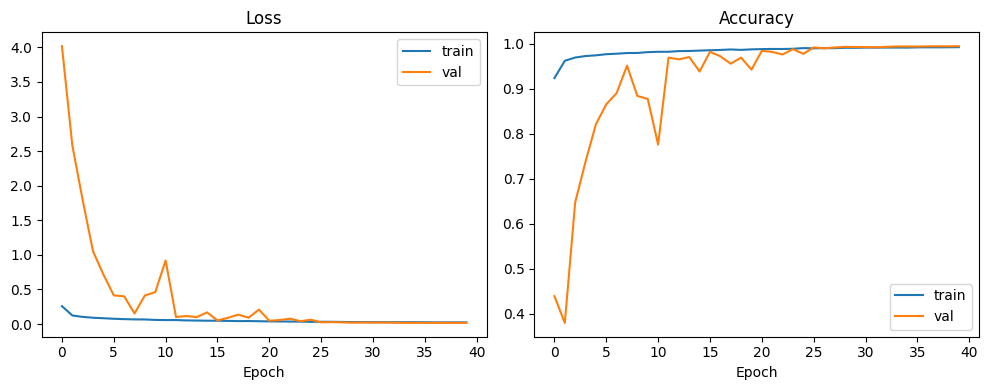

In [7]:
history_dict = history.history
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history_dict.get("loss", []), label="train")
axes[0].plot(history_dict.get("val_loss", []), label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_dict.get("accuracy", []), label="train")
axes[1].plot(history_dict.get("val_accuracy", []), label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()

In [8]:
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Validation loss: 0.0171
Validation accuracy: 0.9938
Test loss: 0.0172
Test accuracy: 0.9958


Train label counts: Counter({7: 4843, 0: 4829, 5: 4825, 4: 4816, 1: 4811, 9: 4787, 8: 4782, 2: 4772, 3: 4770, 6: 4765})
Val label counts: Counter({2: 626, 6: 625, 9: 617, 1: 614, 3: 610, 8: 600, 4: 599, 7: 576, 5: 567, 0: 566})
Test label counts: Counter({3: 620, 8: 618, 6: 610, 5: 608, 0: 605, 2: 602, 9: 596, 4: 585, 7: 581, 1: 575})


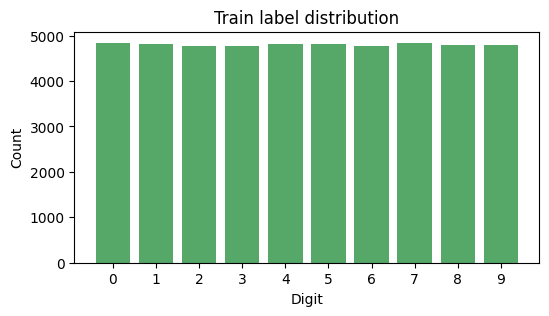

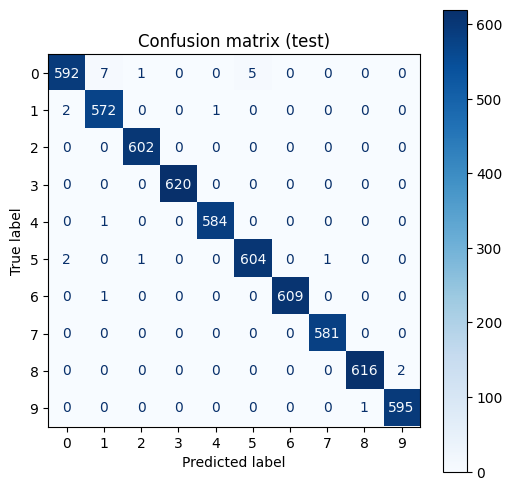

Class weights: {0: 0.9939946158624974, 1: 0.9977135730617335, 2: 1.0058675607711651, 3: 1.0062893081761006, 4: 0.9966777408637874, 5: 0.9948186528497409, 6: 1.0073452256033577, 7: 0.9911212058641338, 8: 1.0037641154328734, 9: 1.0027156883225403}

To address bias and mis-detections:
- Use class_weight in model.fit(..., class_weight=class_weight_dict)
- Ensure inference preprocessing matches training (polarity, padding, resize)
- Visualize failed examples from test set to inspect segmentation issues


In [9]:
# Diagnostics: label distribution, confusion matrix, and class weights
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

label_re = re.compile(r"digit([0-9])\.bmp$", re.IGNORECASE)
train_labels = [int(label_re.search(Path(p).name).group(1)) for p in train_paths]
val_labels = [int(label_re.search(Path(p).name).group(1)) for p in val_paths]
test_labels = [int(label_re.search(Path(p).name).group(1)) for p in test_paths]

print('Train label counts:', Counter(train_labels))
print('Val label counts:', Counter(val_labels))
print('Test label counts:', Counter(test_labels))

# Plot train distribution
fig, ax = plt.subplots(figsize=(6,3))
counts = [train_labels.count(i) for i in range(NUM_CLASSES)]
ax.bar(range(NUM_CLASSES), counts, color='#55A868')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xlabel('Digit')
ax.set_ylabel('Count')
ax.set_title('Train label distribution')
plt.show()

# Confusion matrix on test set
try:    
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    y_true = []
    y_pred = []
    for x_batch, y_batch in test_ds:
        probs = model.predict(x_batch, verbose=0)
        preds = np.argmax(probs, axis=1)
        y_true.extend(y_batch.numpy().tolist())
        y_pred.extend(preds.tolist())
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    disp = ConfusionMatrixDisplay(cm, display_labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title('Confusion matrix (test)')
    plt.show()
except Exception as e:
    print('Install scikit-learn to see confusion matrix:', e)

# Compute class weights for training
try:
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.arange(NUM_CLASSES)
    cw = compute_class_weight('balanced', classes=classes, y=train_labels)
    class_weight_dict = {i: float(w) for i, w in enumerate(cw)}
    print('Class weights:', class_weight_dict)
except Exception as e:
    print('Install scikit-learn to compute class weights automatically:', e)
    total = len(train_labels)
    counts = Counter(train_labels)
    class_weight_dict = {i: float(total / max(1, counts.get(i,1))) for i in range(NUM_CLASSES)}
    print('Heuristic class weights:', class_weight_dict)

print('\nTo address bias and mis-detections:')
print('- Use class_weight in model.fit(..., class_weight=class_weight_dict)')
print('- Ensure inference preprocessing matches training (polarity, padding, resize)')
print('- Visualize failed examples from test set to inspect segmentation issues')

In [10]:
import json

keras_path = out_dir / "model.keras"
tflite_path = out_dir / "model.tflite"
meta_path = out_dir / "model_meta.json"

model.save(keras_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
tflite_path.write_bytes(tflite_model)

meta = {
    "model_type": "mlp",
    "input_size": 64,
    "input_shape": [64, 64, 1],
    "flatten_size": 4096,
    "num_classes": 10,
    "polarity": "dark_ink_on_white",
    "normalization": "luminance_0_to_1",
    "class_labels": list(range(10)),
}
meta_path.write_text(json.dumps(meta, indent=2))

print(f"Saved Keras model: {keras_path}")
print(f"Saved TFLite model: {tflite_path}")
print(f"Saved model metadata: {meta_path}")


INFO:tensorflow:Assets written to: C:\Users\yufss\AppData\Local\Temp\tmpe_juvp7w\assets


INFO:tensorflow:Assets written to: C:\Users\yufss\AppData\Local\Temp\tmpe_juvp7w\assets


Saved artifact at 'C:\Users\yufss\AppData\Local\Temp\tmpe_juvp7w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1679353877072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1679353879376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1679353879568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1679353878416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1679353877840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1679353878608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1679353880336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1679353881296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1679353880912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1679353880144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1679

## Shared image path
Set `image_path` once for both single-digit and multi-digit predictions.

In [31]:
image_path = r"C:\\Users\\yufss\\Downloads\\WhatsApp Image 2026-05-18 at 11.01.19 PM.jpeg"
# Replace with your own file path, e.g. r"C:\\path\\to\\digits_photo.jpg"
invert = False


## Predict on your own image
Set `image_path` in the shared path cell, then run this cell. Use `invert=True` only for light digits on dark paper. Normal black ink on white paper should use `invert=False`, matching MAHDBase training images.

In [32]:
import importlib.util

def prepare_single_image(image_path: str, invert: bool = False) -> tuple[np.ndarray, np.ndarray]:
    if importlib.util.find_spec("cv2") is None:
        raise ImportError("opencv-python not installed. Run: pip install opencv-python")

    import cv2

    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    threshold_type = cv2.THRESH_BINARY if invert else cv2.THRESH_BINARY_INV
    _, ink_mask = cv2.threshold(blur, 0, 255, threshold_type + cv2.THRESH_OTSU)

    # Convert the foreground mask to the model contract: black digit on white background.
    model_image = 255 - ink_mask

    h, w = model_image.shape
    size = max(h, w)
    square = np.full((size, size), 255, dtype=model_image.dtype)
    y_off = (size - h) // 2
    x_off = (size - w) // 2
    square[y_off:y_off + h, x_off:x_off + w] = model_image
    resized = cv2.resize(square, IMG_SIZE, interpolation=cv2.INTER_AREA)
    image_array = resized.astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=(0, -1))
    return resized, image_array

def predict_single_image(image_path: str, invert: bool = False) -> tuple[int, np.ndarray]:
    _, image_array = prepare_single_image(image_path, invert=invert)
    probs = model.predict(image_array, verbose=0)[0]
    pred = int(np.argmax(probs))
    return pred, probs

tta_augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.055, fill_mode="constant", fill_value=1.0),
        layers.RandomZoom(0.10, fill_mode="constant", fill_value=1.0),
    ],
    name="tta_augmentation",
)

def predict_single_image_tta(
    image_array: np.ndarray,
    tta: int = 8,
) -> tuple[int, np.ndarray]:
    batch = tf.repeat(image_array, repeats=tta, axis=0)
    augmented = tta_augmentation(batch, training=True)
    probs = model.predict(augmented, verbose=0)
    mean_probs = np.mean(probs, axis=0)
    pred = int(np.argmax(mean_probs))
    return pred, mean_probs


Predicted digit (TTA): 0


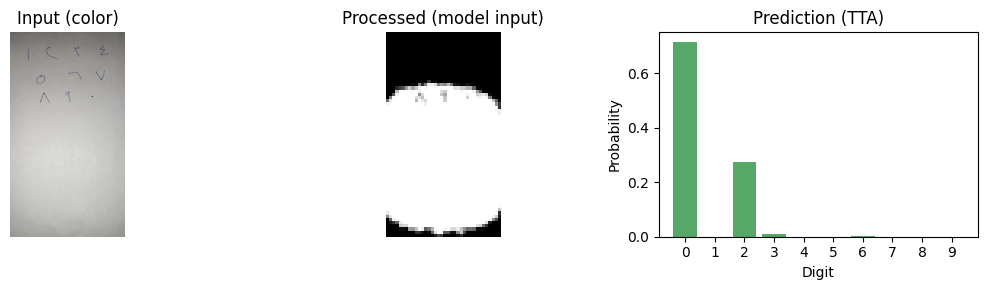

In [33]:
image_path = globals().get("image_path", "")
invert = bool(globals().get("invert", False))

if not image_path:
    raise ValueError("Set image_path in the shared path cell.")
if not Path(image_path).exists():
    raise FileNotFoundError(f"Image not found: {image_path}")

processed, image_array = prepare_single_image(image_path, invert=invert)
pred, probs = predict_single_image_tta(image_array, tta=8)
print(f"Predicted digit (TTA): {pred}")

display_image = Image.open(image_path).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
axes[0].imshow(display_image)
axes[0].axis("off")
axes[0].set_title("Input (color)")

axes[1].imshow(processed, cmap="gray")
axes[1].axis("off")
axes[1].set_title("Processed (model input)")

axes[2].bar(range(NUM_CLASSES), probs, color="#55A868")
axes[2].set_xticks(range(NUM_CLASSES))
axes[2].set_xlabel("Digit")
axes[2].set_ylabel("Probability")
axes[2].set_title("Prediction (TTA)")
plt.tight_layout()


[merge] 134 boxes -> 122 after merging (gap=8px)
Predicted sequence: 00000000000000000005000008600000520000000000000004000000000090007064000300000000000440000070004000000040000000800000000000


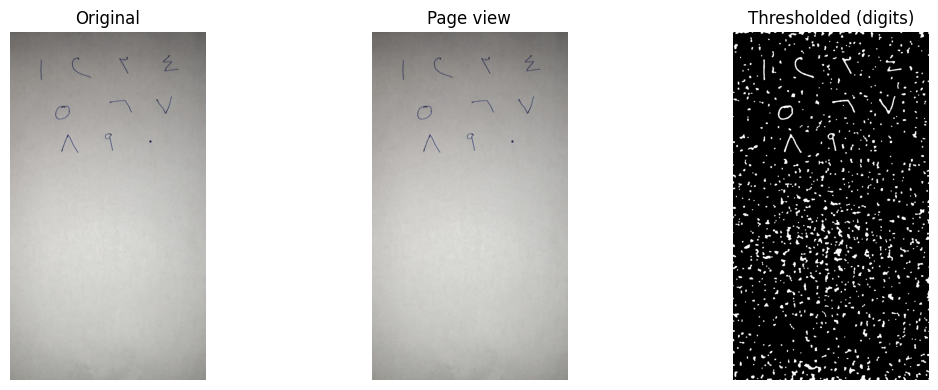

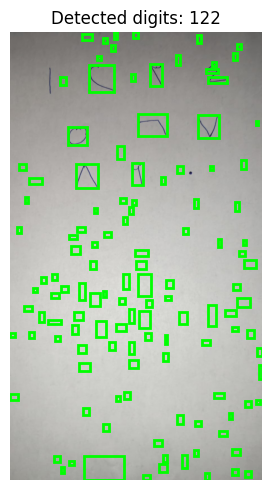

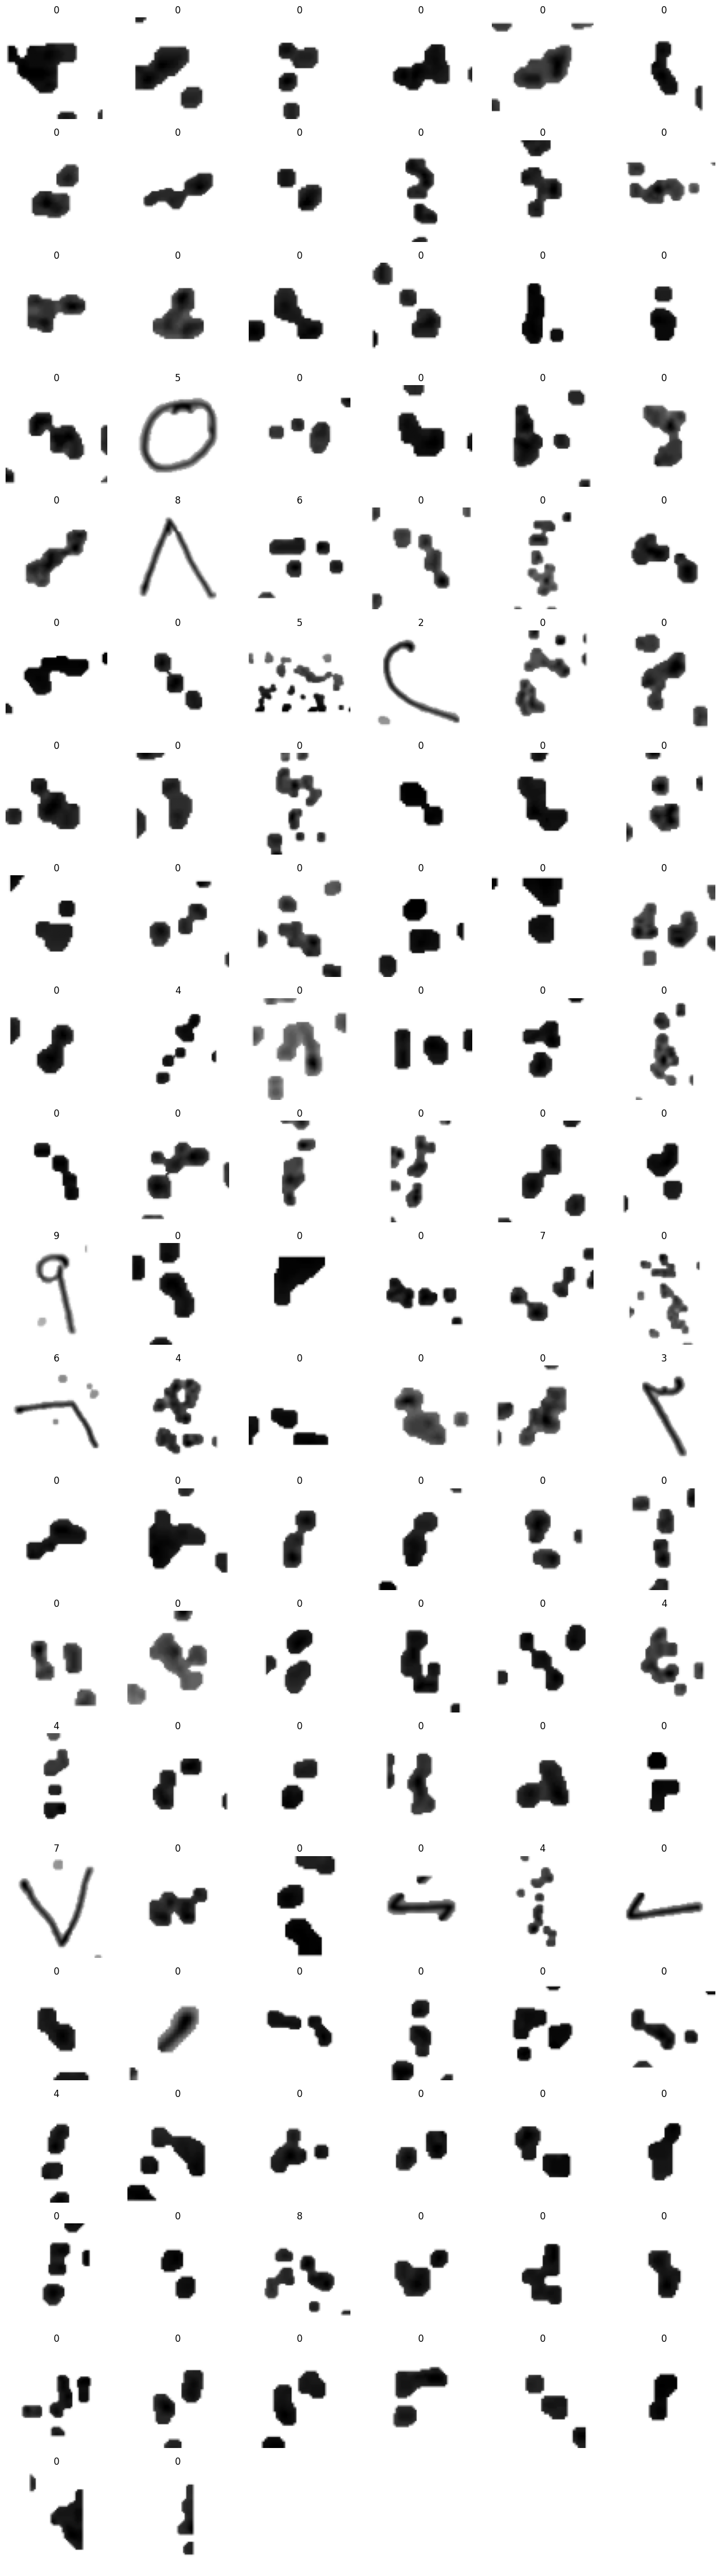

In [34]:
# Multi-digit photo (OpenCV segmentation)
import importlib.util

if importlib.util.find_spec("cv2") is None:
    raise ImportError("opencv-python not installed. Run: pip install opencv-python")

import cv2
from matplotlib import patches

seg_image_path = image_path if "image_path" in globals() else ""
# To override, set seg_image_path = r"C:\\path\\to\\digits_photo.jpg"
sort_right_to_left = False
show_debug = True
use_perspective = False
use_paper_crop = True
invert_for_model = False  # grayscale digits are already dark on white
adaptive_block = 81
adaptive_C = 5
min_area = 120
min_area_tall = 60
min_height_tall = 25
pad = 12
mask_dilate = 1
use_tta = True
tta_repeats = 8
use_dual_preprocess = True
use_blackhat = False
pre_blur = 5
normalize_gray = True
use_color_mask = True
color_min_ratio = 0.00005
blue_threshold = 18
contour_close_iter = 2
contour_dilate_iter = 0
merge_gap_px = 8
clean_open_iter = 2
clean_close_iter = 2
min_fill_ratio = 0.02
max_fill_ratio = 0.6
min_aspect = 0.03
max_aspect = 7.0
max_area_ratio = 0.2
min_width = 2
min_height = 14
min_height_ratio = 0.4

if not seg_image_path:
    raise ValueError("Set image_path in the shared path cell or set seg_image_path here.")
if not Path(seg_image_path).exists():
    raise FileNotFoundError(f"Image not found: {seg_image_path}")

def order_points(pts: np.ndarray) -> np.ndarray:
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def four_point_transform(image: np.ndarray, pts: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    rect = order_points(pts)
    (tl, tr, br, bl) = rect
    width_a = np.linalg.norm(br - bl)
    width_b = np.linalg.norm(tr - tl)
    max_width = int(max(width_a, width_b))
    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)
    max_height = int(max(height_a, height_b))
    if max_width < 20 or max_height < 20:
        return image, np.eye(3, dtype=np.float32)
    dst = np.array(
        [[0, 0], [max_width - 1, 0], [max_width - 1, max_height - 1], [0, max_height - 1]],
        dtype="float32",
    )
    transform = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, transform, (max_width, max_height))
    return warped, transform

def find_page_quad(image_bgr: np.ndarray, min_area_ratio: float = 0.15) -> tuple[np.ndarray | None, np.ndarray]:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.dilate(edges, dilate_kernel, iterations=2)
    contours_info = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    img_h, img_w = image_bgr.shape[:2]
    img_area = float(img_h * img_w)
    for contour in contours[:8]:
        if cv2.contourArea(contour) < min_area_ratio * img_area:
            continue
        peri = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
        if len(approx) == 4:
            return approx.reshape(4, 2), edges
    return None, edges

def _merge_bboxes(bboxes, gap):
    """Iteratively merge bounding boxes within `gap` px of each other."""
    if not bboxes:
        return []
    merged = list(bboxes)
    changed = True
    while changed:
        changed = False
        new_merged = []
        used = [False] * len(merged)
        for i in range(len(merged)):
            if used[i]:
                continue
            x1, y1, w1, h1 = merged[i]
            for j in range(i + 1, len(merged)):
                if used[j]:
                    continue
                x2, y2, w2, h2 = merged[j]
                # Gap between the two intervals on each axis
                h_gap = max(0, max(x1, x2) - min(x1 + w1, x2 + w2))
                v_gap = max(0, max(y1, y2) - min(y1 + h1, y2 + h2))
                # Merge if close in BOTH dimensions
                if h_gap < gap and v_gap < gap:
                    nx = min(x1, x2)
                    ny = min(y1, y2)
                    nw = max(x1 + w1, x2 + w2) - nx
                    nh = max(y1 + h1, y2 + h2) - ny
                    x1, y1, w1, h1 = nx, ny, nw, nh
                    used[j] = True
                    changed = True
            new_merged.append((x1, y1, w1, h1))
        merged = new_merged
    return merged

def segment_digits_with_opencv(
    image_path: str,
    min_area: int | None = None,
    pad: int = 4,
    sort_right_to_left: bool = False,
    show_debug: bool = False,
    invert_for_model: bool = False,
    merge_gap_px: int = 20,
    ) -> tuple[np.ndarray, np.ndarray, list[tuple[int, int, int, int]], list[np.ndarray], list[np.ndarray], list[np.ndarray]]:
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    img_h, img_w = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    roi_bgr = image_bgr
    display_rgb = image_rgb
    debug_mid = None
    debug_mid_title = None
    edges = None
    page_quad = None

    def warp_if_reasonable(quad: np.ndarray) -> np.ndarray | None:
        warped, _ = four_point_transform(image_bgr, quad)
        h, w = warped.shape[:2]
        if w < 0.2 * img_w or h < 0.2 * img_h:
            return None
        ratio = w / h if h else 0
        if ratio < 0.4 or ratio > 2.5:
            return None
        return warped

    if use_paper_crop:
        hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
        paper_lower = np.array((0, 0, 80), dtype=np.uint8)
        paper_upper = np.array((180, 120, 255), dtype=np.uint8)
        paper_mask = cv2.inRange(hsv, paper_lower, paper_upper)
        paper_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
        paper_mask = cv2.morphologyEx(paper_mask, cv2.MORPH_CLOSE, paper_kernel, iterations=2)
        paper_mask = cv2.morphologyEx(paper_mask, cv2.MORPH_OPEN, paper_kernel, iterations=1)
        contours_info = cv2.findContours(paper_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]
        if contours:
            largest = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest)
            if area > 0.15 * img_h * img_w:
                peri = cv2.arcLength(largest, True)
                approx = cv2.approxPolyDP(largest, 0.02 * peri, True)
                if len(approx) == 4:
                    warped = warp_if_reasonable(approx.reshape(4, 2))
                    if warped is not None:
                        roi_bgr = warped
                        display_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
                        debug_mid = display_rgb
                        debug_mid_title = "Page view"
                        page_quad = approx
                if page_quad is None:
                    x, y, w, h = cv2.boundingRect(largest)
                    roi_bgr = image_bgr[y:y + h, x:x + w]
                    display_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
                    debug_mid = paper_mask
                    debug_mid_title = "Paper mask"

    if use_perspective and page_quad is None:
        page_quad, edges = find_page_quad(image_bgr)
        if page_quad is not None:
            warped = warp_if_reasonable(page_quad)
            if warped is not None:
                roi_bgr = warped
                display_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
                debug_mid = display_rgb
                debug_mid_title = "Page view"
            else:
                page_quad = None
    if edges is not None and debug_mid is None:
        debug_mid = edges
        debug_mid_title = "Edges"

    roi_gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    roi_gray = clahe.apply(roi_gray)
    if pre_blur > 0:
        roi_gray = cv2.GaussianBlur(roi_gray, (pre_blur, pre_blur), 0)
    if normalize_gray:
        roi_gray = cv2.normalize(roi_gray, np.empty_like(roi_gray), 0, 255, cv2.NORM_MINMAX)
    roi_h, roi_w = roi_gray.shape
    mask_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    color_ratio = 0.0
    color_mask = None
    if use_color_mask:
        hsv_roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
        hsv_lower = np.array((85, 20, 20), dtype=np.uint8)
        hsv_upper = np.array((150, 255, 255), dtype=np.uint8)
        hsv_mask = cv2.inRange(hsv_roi, hsv_lower, hsv_upper)
        blue = roi_bgr[:, :, 0].astype(np.float32)
        green = roi_bgr[:, :, 1].astype(np.float32)
        red = roi_bgr[:, :, 2].astype(np.float32)
        blue_emphasis = blue - 0.5 * red - 0.5 * green
        blue_emphasis = np.clip(blue_emphasis, 0, 255).astype(np.uint8)
        _, blue_mask = cv2.threshold(blue_emphasis, blue_threshold, 255, cv2.THRESH_BINARY)
        color_mask = cv2.bitwise_or(hsv_mask, blue_mask)
        color_mask = cv2.morphologyEx(color_mask, cv2.MORPH_OPEN, mask_kernel, iterations=1)
        color_mask = cv2.morphologyEx(color_mask, cv2.MORPH_CLOSE, mask_kernel, iterations=1)
        color_ratio = cv2.countNonZero(color_mask) / max(1, roi_h * roi_w)

    block_size = adaptive_block
    if block_size % 2 == 0:
        block_size += 1
    adaptive = cv2.adaptiveThreshold(
        roi_gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        block_size,
        adaptive_C,
    )
    binary_gray = adaptive
    if use_blackhat:
        bh_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
        blackhat = cv2.morphologyEx(roi_gray, cv2.MORPH_BLACKHAT, bh_kernel)
        blackhat = cv2.normalize(blackhat, np.empty_like(blackhat), 0, 255, cv2.NORM_MINMAX)
        _, bh_bin = cv2.threshold(blackhat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        binary_gray = cv2.bitwise_or(adaptive, bh_bin)
    binary_gray = cv2.medianBlur(binary_gray, 3)
    clean_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary_gray = cv2.morphologyEx(binary_gray, cv2.MORPH_OPEN, clean_kernel, iterations=clean_open_iter)
    binary_gray = cv2.morphologyEx(binary_gray, cv2.MORPH_CLOSE, clean_kernel, iterations=clean_close_iter)

    if color_mask is not None and color_ratio > color_min_ratio:
        binary_clean = cv2.bitwise_or(binary_gray, color_mask)
        binary_clean = cv2.morphologyEx(binary_clean, cv2.MORPH_OPEN, clean_kernel, iterations=clean_open_iter)
        binary_clean = cv2.morphologyEx(binary_clean, cv2.MORPH_CLOSE, clean_kernel, iterations=clean_close_iter)
    else:
        binary_clean = binary_gray

    contour_close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary_for_contours = cv2.morphologyEx(
        binary_clean,
        cv2.MORPH_CLOSE,
        contour_close_kernel,
        iterations=contour_close_iter,
    )
    contour_dilate_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary_for_contours = cv2.dilate(
        binary_for_contours,
        contour_dilate_kernel,
        iterations=contour_dilate_iter,
    )

    contours_info = cv2.findContours(binary_for_contours, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]

    if min_area is None:
        min_area = max(60, int(0.0005 * roi_h * roi_w))

    boxes: list[tuple[int, int, int, int]] = []
    max_area = max_area_ratio * roi_h * roi_w
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h
        if area < min_area and not (h >= min_height_tall and area >= min_area_tall):
            continue
        if area > max_area:
            continue
        if w < min_width or h < min_height:
            continue
        if w > 0.98 * roi_w and h > 0.98 * roi_h:
            continue
        aspect = w / h if h else 0
        if aspect < min_aspect or aspect > max_aspect:
            continue
        fill_ratio = cv2.countNonZero(binary_clean[y:y + h, x:x + w]) / float(area)
        if fill_ratio < min_fill_ratio or fill_ratio > max_fill_ratio:
            continue
        boxes.append((x, y, w, h))

    # --- Merge nearby bounding boxes (fixes digit fragmentation) ---
    if merge_gap_px > 0:
        before_count = len(boxes)
        boxes = _merge_bboxes(boxes, merge_gap_px)
        if show_debug:
            print(f"[merge] {before_count} boxes -> {len(boxes)} after merging (gap={merge_gap_px}px)")

    if boxes:
        median_h = float(np.median([h for _, _, _, h in boxes]))
        min_h = min_height_ratio * median_h
        boxes = [b for b in boxes if b[3] >= min_h]

    boxes.sort(key=lambda b: b[0], reverse=sort_right_to_left)

    crops = []
    crops_alt = []
    crops_raw = []
    for x, y, w, h in boxes:
        x0 = max(x - pad, 0)
        y0 = max(y - pad, 0)
        x1 = min(x + w + pad, roi_w)
        y1 = min(y + h + pad, roi_h)
        crop_mask = binary_clean[y0:y1, x0:x1]
        crop_gray = roi_gray[y0:y1, x0:x1]
        if mask_dilate > 0:
            crop_mask = cv2.dilate(crop_mask, mask_kernel, iterations=mask_dilate)
            crop_mask = cv2.morphologyEx(crop_mask, cv2.MORPH_CLOSE, mask_kernel, iterations=1)
        masked = np.where(crop_mask > 0, crop_gray, 255).astype("uint8")
        masked = cv2.normalize(masked, np.empty_like(masked), 0, 255, cv2.NORM_MINMAX)
        h_c, w_c = masked.shape
        size = max(h_c, w_c)
        square = np.full((size, size), 255, dtype=masked.dtype)
        y_off = (size - h_c) // 2
        x_off = (size - w_c) // 2
        square[y_off:y_off + h_c, x_off:x_off + w_c] = masked
        resized_gray = cv2.resize(square, IMG_SIZE, interpolation=cv2.INTER_AREA)
        if invert_for_model:
            resized_gray = 255 - resized_gray
        norm = resized_gray.astype("float32") / 255.0
        norm = np.expand_dims(norm, axis=-1)
        crops.append(norm)
        crops_raw.append(resized_gray)
        if use_dual_preprocess:
            blurred = cv2.GaussianBlur(masked, (3, 3), 0)
            _, ink_mask = cv2.threshold(
                blurred,
                0,
                255,
                cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU,
            )
            model_bin = 255 - ink_mask
            resized_bin = cv2.resize(model_bin, IMG_SIZE, interpolation=cv2.INTER_AREA)
            if invert_for_model:
                resized_bin = 255 - resized_bin
            norm_bin = resized_bin.astype("float32") / 255.0
            norm_bin = np.expand_dims(norm_bin, axis=-1)
            crops_alt.append(norm_bin)

    if show_debug:
        if debug_mid is None:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].imshow(image_rgb)
            axes[0].set_title("Original")
            axes[0].axis("off")
            axes[1].imshow(binary_for_contours, cmap="gray")
            axes[1].set_title("Thresholded (digits)")
            axes[1].axis("off")
        else:
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(image_rgb)
            axes[0].set_title("Original")
            axes[0].axis("off")
            if debug_mid.ndim == 2:
                axes[1].imshow(debug_mid, cmap="gray")
            else:
                axes[1].imshow(debug_mid)
            axes[1].set_title(debug_mid_title or "Debug")
            axes[1].axis("off")
            axes[2].imshow(binary_for_contours, cmap="gray")
            axes[2].set_title("Thresholded (digits)")
            axes[2].axis("off")
        plt.tight_layout()

    return display_rgb, binary_for_contours, boxes, crops, crops_raw, crops_alt

display_rgb, binary, boxes, crops, crops_raw, crops_alt = segment_digits_with_opencv(
    seg_image_path,
    min_area=min_area,
    pad=pad,
    sort_right_to_left=sort_right_to_left,
    show_debug=show_debug,
    invert_for_model=invert_for_model,
    merge_gap_px=merge_gap_px,
    )

if not boxes:
    print("No digits detected. Try adjusting min_area or lighting.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(display_rgb)
    for x, y, w, h in boxes:
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
    ax.set_title(f"Detected digits: {len(boxes)}")
    ax.axis("off")
    plt.tight_layout()

    batch = np.stack(crops, axis=0)
    if use_tta and "tta_augmentation" not in globals():
        tta_augmentation = keras.Sequential(
            [
                layers.RandomRotation(0.055, fill_mode="constant", fill_value=1.0),
                layers.RandomZoom(0.10, fill_mode="constant", fill_value=1.0),
            ],
            name="tta_augmentation",
        )

    def predict_batch(batch: np.ndarray) -> np.ndarray:
        if use_tta:
            batch_tta = tf.repeat(batch, repeats=tta_repeats, axis=0)
            augmented = tta_augmentation(batch_tta, training=True)
            probs = model.predict(augmented, verbose=0)
            return probs.reshape(len(batch), tta_repeats, -1).mean(axis=1)
        return model.predict(batch, verbose=0)

    probs = predict_batch(batch)
    if use_dual_preprocess and len(crops_alt) == len(crops):
        batch_alt = np.stack(crops_alt, axis=0)
        probs_alt = predict_batch(batch_alt)
        alt_better = probs_alt.max(axis=1) > probs.max(axis=1)
        probs[alt_better] = probs_alt[alt_better]
    preds = np.argmax(probs, axis=1)

    n = len(crops_raw)
    cols = min(6, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(crops_raw[i], cmap="gray")
            ax.set_title(str(preds[i]))
        ax.axis("off")
    plt.tight_layout()

    print("Predicted sequence:", "".join(str(p) for p in preds))
